In [1]:
import xarray as xr
from scipy.spatial import cKDTree
import shapely.geometry as geom
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from shapely.ops import nearest_points
import tqdm

Archivos:

bathymetry.nc → profundidad

chlorophyll.nc

nitrate.nc

oxygen_dissolved.nc

oxygen_utilization.nc

phosphate.nc

salinity.nc

temperature_celsius.nc

distance_to_coastline.shp

In [2]:
# Crear la grilla 1°×1°
lats = np.arange(-89.5, 90, 0.5)   # centro de celda
lons = np.arange(-179.5, 180, 0.5)
grid_list = []

for lat in lats:
    for lon in lons:
        grid_list.append({'lat': lat, 'lon': lon})

grid = pd.DataFrame(grid_list)

# Convertir a GeoDataFrame
grid_gdf = gpd.GeoDataFrame(grid, geometry=gpd.points_from_xy(grid.lon, grid.lat))
grid_gdf.set_crs(epsg=4326, inplace=True)

,lat,lon,geometry
0,-89.5,-179.5,POINT (-179.5 -89.5)
1,-89.5,-179.0,POINT (-179 -89.5)
2,-89.5,-178.5,POINT (-178.5 -89.5)
3,-89.5,-178.0,POINT (-178 -89.5)
4,-89.5,-177.5,POINT (-177.5 -89.5)
...,...,...,...
258116,89.5,177.5,POINT (177.5 89.5)
258117,89.5,178.0,POINT (178 89.5)
258118,89.5,178.5,POINT (178.5 89.5)
258119,89.5,179.0,POINT (179 89.5)


In [3]:
# Cargar shapefile de costa y calcular distance_to_coast_km rápido

coast = gpd.read_file("../data/ocean/distance_to_coastline.shp").to_crs(epsg=4326)
grid_gdf = grid_gdf.to_crs(epsg=4326)

# Extraer todos los vértices de la costa
coast_points_list = []

for g in coast.geometry:
    if g is None or g.is_empty:
        continue
    # Polygon
    if g.type == "Polygon":
        coast_points_list.append(np.array(g.exterior.coords))
    # MultiPolygon
    elif g.type == "MultiPolygon":
        for poly in g.geoms:
            coast_points_list.append(np.array(poly.exterior.coords))
    # LineString
    elif g.type == "LineString":
        coast_points_list.append(np.array(g.coords))
    # MultiLineString
    elif g.type == "MultiLineString":
        for line in g.geoms:
            coast_points_list.append(np.array(line.coords))

if not coast_points_list:
    raise ValueError("No se encontraron puntos de costa válidos en el shapefile.")

# Combinar todos los puntos
coast_points = np.vstack(coast_points_list)

# Construir KDTree
tree = cKDTree(coast_points)

# Coordenadas de la grilla
coords = np.column_stack([grid_gdf['lon'], grid_gdf['lat']])

# Calcular distancia mínima
print("Calculando distance_to_coast_km con KDTree...")
distances_deg, _ = tree.query(coords)

# Convertir grados a km (aprox.)
grid_gdf['distance_to_coast_km'] = distances_deg * 111

/tmp/ipykernel_4975/2371294546.py:13: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if g.type == "Polygon":
/tmp/ipykernel_4975/2371294546.py:16: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif g.type == "MultiPolygon":
/tmp/ipykernel_4975/2371294546.py:20: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif g.type == "LineString":


Calculando distance_to_coast_km con KDTree...


In [4]:
# 3️⃣ Extraer variables ambientales desde NetCDF
# -------------------------
def sample_nc_to_points(nc_path, var_name, coords, depth_slice=None):
    ds = xr.open_dataset(nc_path, decode_times=False)
    da = ds[var_name]
    
    # Promediar dimensiones extra
    extra_dims = [d for d in da.dims if d.lower() not in ["lat","latitude","lon","longitude"]]
    if extra_dims:
        da = da.mean(extra_dims)
    
    lat_name = [d for d in da.dims if d.lower() in ["lat","latitude"]][0]
    lon_name = [d for d in da.dims if d.lower() in ["lon","longitude"]][0]
    
    lats = da[lat_name].values
    lons = da[lon_name].values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    values = da.values.flatten()
    
    tree = cKDTree(np.column_stack([lon_grid.flatten(), lat_grid.flatten()]))
    _, idx = tree.query(coords)
    return values[idx]

nc_files = {
    'temperature': ('../data/ocean/temperature_celsius.nc', 't_an'),
    'salinity': ('../data/ocean/salinity.nc', 's_an'),
    'chlorophyll': ('../data/ocean/chlorophyll.nc', 'trend'),
    'nitrate': ('../data/ocean/nitrate.nc', 'n_an'),
    'phosphate': ('../data/ocean/phosphate.nc', 'p_an'),
    'oxygen_dissolved': ('../data/ocean/oxygen_dissolved.nc', 'o_an'),
    'oxygen_utilization': ('../data/ocean/oxygen_utilization.nc', 'A_an')
}

for var, (file, nc_var) in nc_files.items():
    print(f"Extrayendo {var}...")
    grid_gdf[var] = sample_nc_to_points(file, nc_var, coords)


Extrayendo temperature...
Extrayendo salinity...
Extrayendo chlorophyll...
Extrayendo nitrate...
Extrayendo phosphate...
Extrayendo oxygen_dissolved...
Extrayendo oxygen_utilization...


In [5]:
grid_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 258121 entries, 0 to 258120
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   lat                   258121 non-null  float64 
 1   lon                   258121 non-null  float64 
 2   geometry              258121 non-null  geometry
 3   distance_to_coast_km  258121 non-null  float64 
 4   temperature           163553 non-null  float32 
 5   salinity              163553 non-null  float32 
 6   chlorophyll           131353 non-null  float32 
 7   nitrate               163553 non-null  float32 
 8   phosphate             163553 non-null  float32 
 9   oxygen_dissolved      163553 non-null  float32 
 10  oxygen_utilization    163553 non-null  float32 
dtypes: float32(7), float64(3), geometry(1)
memory usage: 14.8 MB


In [6]:
import geopandas as gpd
from shapely.geometry import Point

# Cargar shapefile de land
land = gpd.read_file("../data/ocean/land.shp").to_crs(epsg=4326)

# Convertir grid a GeoDataFrame si no lo es
grid_gdf['geometry'] = [Point(xy) for xy in zip(grid_gdf.lon, grid_gdf.lat)]

# Hacer spatial join: quedarnos solo con puntos que NO están en land
grid_water = grid_gdf[~grid_gdf.geometry.apply(lambda p: land.contains(p).any())].copy()

print(f"Antes: {len(grid_gdf)} celdas, Después (solo agua): {len(grid_water)} celdas")


Antes: 258121 celdas, Después (solo agua): 172729 celdas


In [7]:
grid_water.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 172729 entries, 6510 to 258120
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   lat                   172729 non-null  float64 
 1   lon                   172729 non-null  float64 
 2   geometry              172729 non-null  geometry
 3   distance_to_coast_km  172729 non-null  float64 
 4   temperature           162750 non-null  float32 
 5   salinity              162750 non-null  float32 
 6   chlorophyll           131108 non-null  float32 
 7   nitrate               162750 non-null  float32 
 8   phosphate             162750 non-null  float32 
 9   oxygen_dissolved      162750 non-null  float32 
 10  oxygen_utilization    162750 non-null  float32 
dtypes: float32(7), float64(3), geometry(1)
memory usage: 11.2 MB


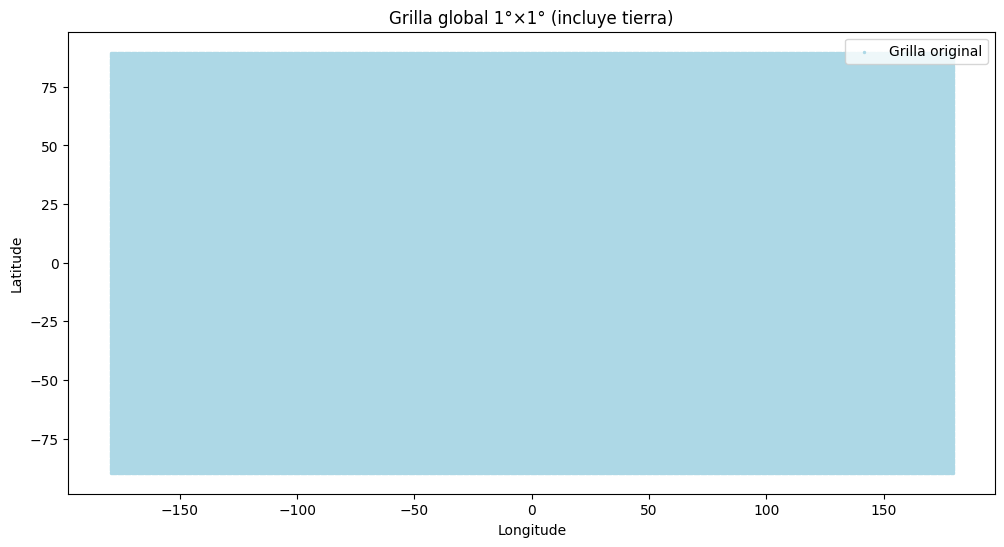

In [8]:
import matplotlib.pyplot as plt

# -------------------------
# Mapa de toda la grilla (grid_gdf)
# -------------------------
fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_gdf.plot(ax=ax, color='lightblue', markersize=2, label='Grilla original')
ax.set_title("Grilla global 1°×1° (incluye tierra)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

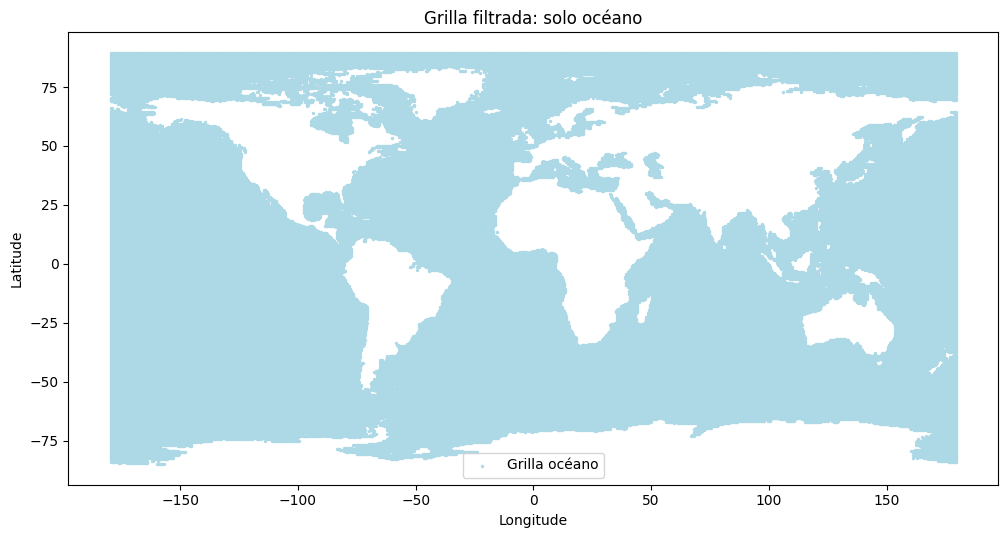

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_water.plot(ax=ax, color='lightblue', markersize=2, label='Grilla océano')
ax.set_title("Grilla filtrada: solo océano")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

In [10]:
grid_clean = grid_water.dropna()


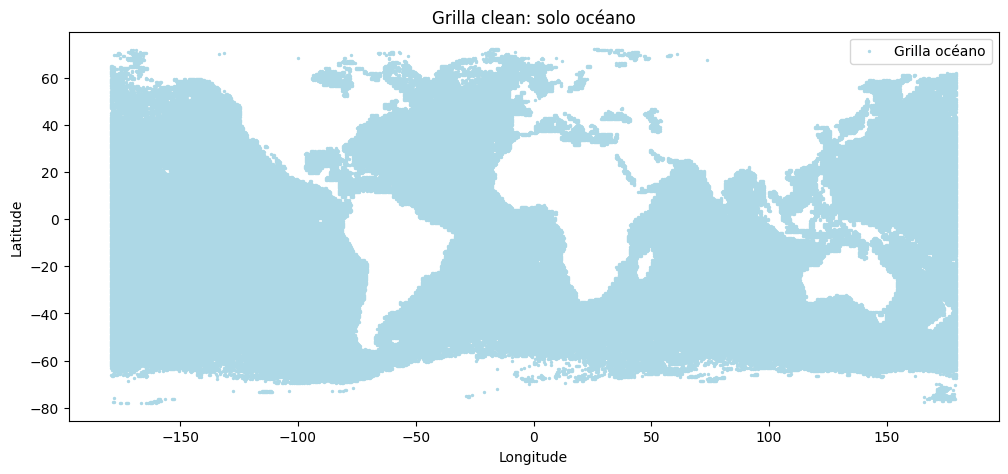

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12,6))
grid_clean.plot(ax=ax, color='lightblue', markersize=2, label='Grilla océano')
ax.set_title("Grilla clean: solo océano")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

In [12]:
grid_clean

,lat,lon,geometry,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization
16545,-78.0,-175.5,POINT (-175.5 -78),543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695
16546,-78.0,-175.0,POINT (-175 -78),533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695
16550,-78.0,-173.0,POINT (-173 -78),543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039
16551,-78.0,-172.5,POINT (-172.5 -78),540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039
16552,-78.0,-172.0,POINT (-172 -78),535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039
...,...,...,...,...,...,...,...,...,...,...,...
232566,72.0,-15.0,POINT (-15 72),425.634963,0.289420,34.764435,0.504466,11.316046,0.823883,318.571198,32.765865
232647,72.0,25.5,POINT (25.5 72),94.266326,6.833642,34.894951,0.065487,6.138589,0.608244,298.023193,4.414944
232649,72.0,26.5,POINT (26.5 72),110.341777,6.723017,34.888157,0.365244,5.862425,0.607004,298.572815,4.962784
232650,72.0,27.0,POINT (27 72),111.642511,6.723017,34.888157,-0.597254,5.862425,0.607004,298.572815,4.962784


In [13]:
grid_clean.to_file("../data/grid_ocean/grilla_agua.gpkg", driver="GPKG")
# Solo columnas numéricas
grid_clean.drop(columns='geometry').to_parquet("../data/grid_ocean/grilla_agua.parquet", index=False)
print("✅ Dataset final listo para clustering")

✅ Dataset final listo para clustering


### Clustering

In [42]:
import pandas as pd

# Cargar Parquet
df = pd.read_parquet("../data/grid_ocean/grilla_agua.parquet")

# Ver columnas
print(df.columns)
print(df.shape)


Index(['lat', 'lon', 'distance_to_coast_km', 'temperature', 'salinity',
       'chlorophyll', 'nitrate', 'phosphate', 'oxygen_dissolved',
       'oxygen_utilization'],
      dtype='object')
(127013, 10)


| Modelo                         | Pros                                                               | Contras                                            | Comentario                                                                    |
| ------------------------------ | ------------------------------------------------------------------ | -------------------------------------------------- | ----------------------------------------------------------------------------- |
| **KMeans**                     | Simple, rápido, fácil de interpretar. Buen punto de partida.       | Necesita definir `k` (número de clusters).         | Adecuado para datos normalizados. Perfecto si quieres 5–10 perfiles globales. |
| **MiniBatchKMeans**            | Versión de KMeans que funciona rápido con datasets grandes.        | Menos preciso que KMeans completo.                 | Ideal si tu grilla es muy grande (~>50k celdas).                              |
| **DBSCAN**                     | Detecta clusters de forma irregular y outliers.                    | Difícil escoger `eps` y `min_samples` globalmente. | Útil si quieres hotspots y zonas con densidad variable.                       |
| **Gaussian Mixture (GMM)**     | Permite clusters “difusos” y asigna probabilidades.                | Más lento y sensible a outliers.                   | Bueno si quieres perfiles ecológicos probabilísticos.                         |
| **Agglomerative/Hierarchical** | No requiere número de clusters exacto (puedes cortar dendrograma). | Lento en datasets grandes.                         | Útil para análisis exploratorio o ver jerarquía ecológica.                    |


Primero KMeans o MiniBatchKMeans: rápido y fácil de interpretar.

In [43]:
from sklearn.preprocessing import StandardScaler
# Escalar variables
features = ['distance_to_coast_km','temperature','salinity','chlorophyll',
            'nitrate','phosphate','oxygen_dissolved','oxygen_utilization']

X = df[features].values
X_scaled = StandardScaler().fit_transform(X)


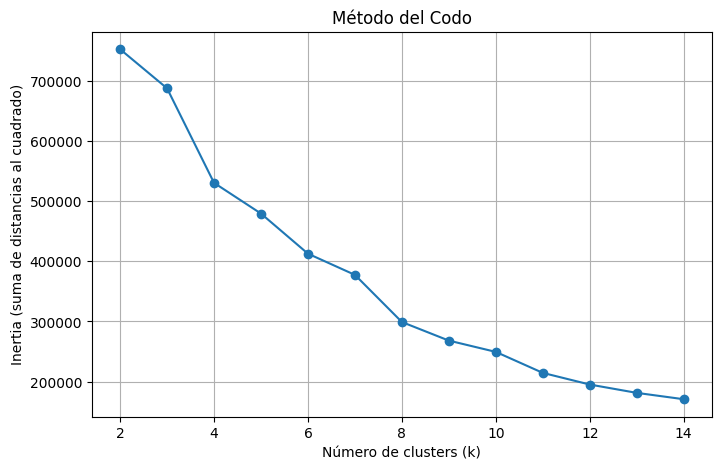

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# -------------------------
# 2️⃣ Método del codo (Elbow)
# -------------------------
inertia = []
K_range = range(2, 15)  # probar de 2 a 15 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  # suma de distancias al cuadrado dentro de cada cluster

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia (suma de distancias al cuadrado)')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

# -------------------------



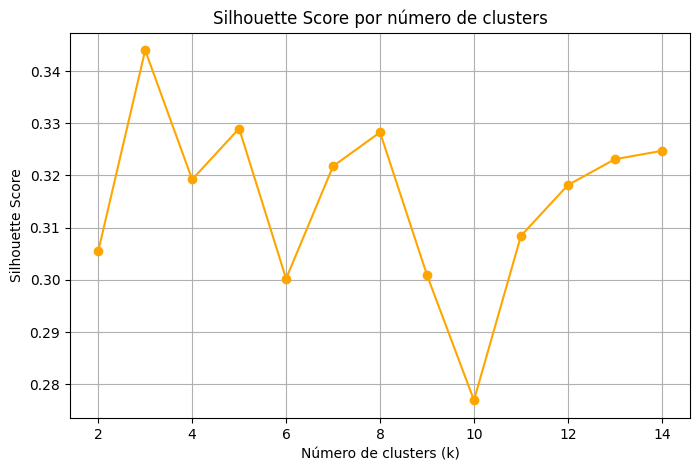

In [45]:
import numpy as np

# 3️⃣ Método Silhouette Score
# -------------------------

# 10k puntos aleatorios
sample_idx = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
X_sample = X_scaled[sample_idx]

sil_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o', color='orange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por número de clusters')
plt.grid(True)
plt.show()

Codo: busca el punto donde la línea de inertia deja de bajar de forma pronunciada. Ahí está el “codo” → buen número de clusters.

Silhouette: busca el máximo → el k donde los clusters son más coherentes y separados.

Probamos con K = 3, 5, 6 y 7

In [46]:
# 2️⃣ Entrenar KMeans para k=5,6,7
# -------------------------
cluster_results = {}

for k in [5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    df[f'cluster_{k}'] = labels
    cluster_results[k] = kmeans
    print(f"KMeans con {k} clusters completado.")


KMeans con 5 clusters completado.
KMeans con 6 clusters completado.
KMeans con 7 clusters completado.


In [47]:
import geopandas as gpd
grid_gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

<Figure size 1200x600 with 0 Axes>

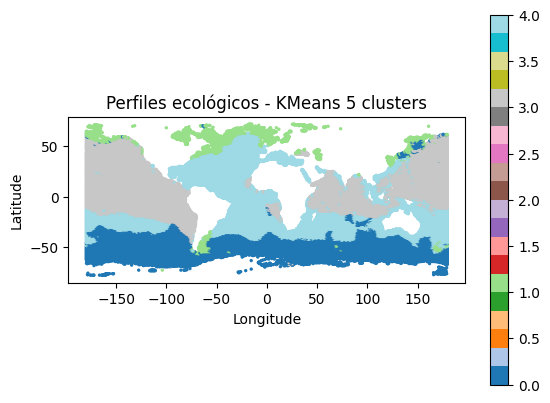

<Figure size 1200x600 with 0 Axes>

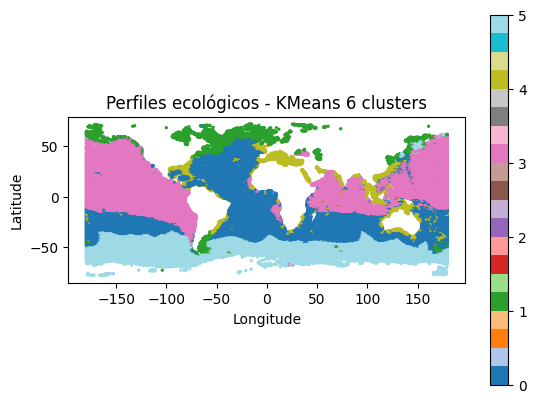

<Figure size 1200x600 with 0 Axes>

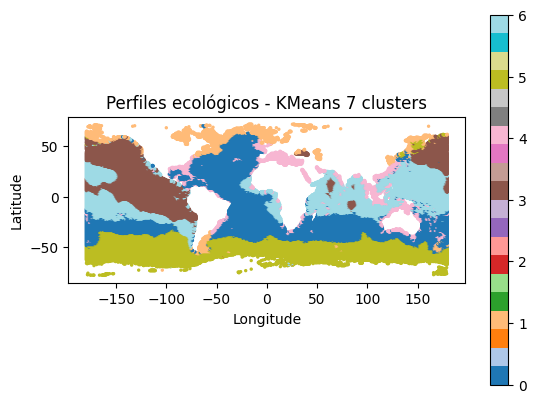

In [48]:
for k in [5,6,7]:
    plt.figure(figsize=(12,6))
    grid_gdf.plot(column=f'cluster_{k}', cmap='tab20', markersize=2, legend=True)
    plt.title(f"Perfiles ecológicos - KMeans {k} clusters")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.show()

In [49]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# 3️⃣ Calcular medias por cluster
for k in [5,6,7]:
    print(f"\n=== Medias de variables por cluster (k={k}) ===")
    print(df.groupby(f'cluster_{k}')[features].mean())



=== Medias de variables por cluster (k=5) ===
           distance_to_coast_km  temperature   salinity  chlorophyll  \
cluster_5                                                              
0                   1123.567079     3.684880  34.488426     1.497318   
1                    227.127088     4.759461  32.609127     0.960865   
2                    317.600858     0.244107  34.535980 -1120.288208   
3                    682.457293     8.958219  34.606510    -0.058779   
4                    560.724956    11.158368  35.185234     0.323362   

             nitrate  phosphate  oxygen_dissolved  oxygen_utilization  
cluster_5                                                              
0          26.777117   1.882050        229.695740           94.592758  
1          10.057297   0.954944        294.823334           26.208197  
2          31.178432   2.124543        246.713226          103.628891  
3          27.525665   2.040388        128.058411          165.236298  
4          16.58

In [50]:
# Diccionario de mapeo
cluster_names = {
    0: "open_sea_temperate",
    1: "cold_shelf",
    2: "invalid_data",   # opcional: eliminar filas con cluster 2 más adelante
    3: "subpolar_open_sea",
    4: "warm_coastal",
    5: "cold_open_sea"
}

# Crear nueva columna con nombres descriptivos
grid_gdf['profile_eco'] = grid_gdf['cluster_6'].map(cluster_names)

# Opcional: eliminar filas con datos inválidos
grid_gdf = grid_gdf[grid_gdf['profile_eco'] != "invalid_data"]

# Revisar resultados
grid_gdf[['cluster_6','profile_eco']]


,cluster_6,profile_eco
0,5,cold_open_sea
1,5,cold_open_sea
2,5,cold_open_sea
3,5,cold_open_sea
4,5,cold_open_sea
...,...,...
127008,1,cold_shelf
127009,1,cold_shelf
127010,1,cold_shelf
127011,1,cold_shelf


In [51]:
(grid_gdf["profile_eco"]).value_counts()

profile_eco
subpolar_open_sea     42937
open_sea_temperate    42489
cold_open_sea         31145
cold_shelf             5601
warm_coastal           4839
Name: count, dtype: int64

In [52]:
grid_gdf

,lat,lon,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,cluster_5,cluster_6,cluster_7,geometry,profile_eco
0,-78.0,-175.5,543.707048,-1.775068,34.395912,1.680748,27.419722,1.907441,311.153168,59.152695,0,5,5,POINT (-175.5 -78),cold_open_sea
1,-78.0,-175.0,533.294654,-1.775068,34.395912,1.243596,27.419722,1.907441,311.153168,59.152695,0,5,5,POINT (-175 -78),cold_open_sea
2,-78.0,-173.0,543.143622,-1.808737,34.373737,-0.760849,27.574869,1.912899,312.213226,57.888039,0,5,5,POINT (-173 -78),cold_open_sea
3,-78.0,-172.5,540.559218,-1.808737,34.373737,-0.805667,27.574869,1.912899,312.213226,57.888039,0,5,5,POINT (-172.5 -78),cold_open_sea
4,-78.0,-172.0,535.905487,-1.808737,34.373737,-0.708566,27.574869,1.912899,312.213226,57.888039,0,5,5,POINT (-172 -78),cold_open_sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127008,72.0,-15.0,425.634963,0.289420,34.764435,0.504466,11.316046,0.823883,318.571198,32.765865,1,1,1,POINT (-15 72),cold_shelf
127009,72.0,25.5,94.266326,6.833642,34.894951,0.065487,6.138589,0.608244,298.023193,4.414944,1,1,1,POINT (25.5 72),cold_shelf
127010,72.0,26.5,110.341777,6.723017,34.888157,0.365244,5.862425,0.607004,298.572815,4.962784,1,1,1,POINT (26.5 72),cold_shelf
127011,72.0,27.0,111.642511,6.723017,34.888157,-0.597254,5.862425,0.607004,298.572815,4.962784,1,1,1,POINT (27 72),cold_shelf


In [53]:
mp_gdf = gpd.read_file(
    "../data/GeoDataFrame/gdf_microplastics.gpkg",
    crs="EPSG:4326"
)

mp_gdf = mp_gdf.reset_index(drop=True)
mp_gdf["mp_id"] = mp_gdf.index


mp_with_env = gpd.sjoin_nearest(
    mp_gdf,
    grid_gdf.drop(columns=['lat','lon']),  # opcional, mantener solo variables + geometry
    how='left',
    distance_col='dist_deg'
)


mp_with_env = (
    mp_with_env
    .sort_values("dist_deg", ascending=False)
    .drop_duplicates(subset=['mp_id'])
)
mp_with_env

/usr/local/python/3.12.1/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(


/usr/local/python/3.12.1/lib/python3.12/site-packages/geopandas/array.py:407: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,lat,lon,geometry,mp_id,index_right,distance_to_coast_km,...,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,cluster_5,cluster_6,cluster_7,profile_eco,dist_deg
8839,0.000000,pieces/m3,0-0.0005,0.20000,77.853450,107.355183,POINT (107.35518 77.85345),8839,126691,46.372476,...,-0.269037,2.339194,0.525118,260.963562,41.858490,1,1,1,cold_shelf,35.402928
12525,1.658375,pieces/m3,1-10,0.08000,77.841417,106.833958,POINT (106.83396 77.84142),12525,126691,46.372476,...,-0.269037,2.339194,0.525118,260.963562,41.858490,1,1,1,cold_shelf,34.901256
12526,1.517451,pieces/m3,1-10,0.08000,77.648175,112.619233,POINT (112.61923 77.64818),12526,123254,31.050946,...,-0.110099,18.573574,1.782114,317.342865,43.236401,1,1,1,cold_shelf,33.359059
12561,1.012146,pieces/m3,1-10,0.08000,77.592725,113.229308,POINT (113.22931 77.59272),12561,123254,31.050946,...,-0.110099,18.573574,1.782114,317.342865,43.236401,1,1,1,cold_shelf,32.860812
12562,2.392344,pieces/m3,1-10,0.08000,77.961375,104.183783,POINT (104.18378 77.96138),12562,126691,46.372476,...,-0.269037,2.339194,0.525118,260.963562,41.858490,1,1,1,cold_shelf,32.418126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6852,0.004000,pieces/m3,0.0005-0.005,0.00045,16.000000,-32.000000,POINT (-32 16),6852,93900,746.243101,...,-0.469347,19.265440,1.279581,189.611328,98.085228,4,0,0,open_sea_temperate,0.000000
4662,0.269980,pieces/m3,0.005-1,0.33500,31.000000,-74.000000,POINT (-74 31),4662,106999,487.458258,...,-0.584247,12.272102,0.788425,227.396851,46.400288,4,0,0,open_sea_temperate,0.000000
8581,0.000000,pieces/m3,0-0.0005,0.33300,31.000000,-145.000000,POINT (-145 31),8581,106925,1665.252893,...,-0.896023,26.837103,1.940398,137.535690,162.430511,3,3,3,subpolar_open_sea,0.000000
8579,0.007000,pieces/m3,0.005-1,0.33300,31.000000,-137.000000,POINT (-137 31),8579,106941,1715.646725,...,-0.065886,27.365776,1.980577,133.753433,164.970383,3,3,3,subpolar_open_sea,0.000000


In [54]:
mp_with_env = (
    mp_with_env
    .sort_values("mp_id")
)

In [55]:
mp_with_env 


,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,lat,lon,geometry,mp_id,index_right,distance_to_coast_km,...,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,cluster_5,cluster_6,cluster_7,profile_eco,dist_deg
0,0.000000,pieces/m3,0-0.0005,0.3350,45.280000,-60.290000,POINT (-60.29 45.28),0,117455,60.127269,...,0.509678,5.787156,0.834564,265.093384,57.033932,1,1,1,cold_shelf,0.350000
1,0.002276,pieces/m3,0.0005-0.005,0.3350,40.930000,-70.650000,POINT (-70.65 40.93),1,114726,39.954054,...,0.336776,5.251710,0.567093,248.744659,25.638559,1,1,4,cold_shelf,0.165529
2,0.004320,pieces/m3,0.0005-0.005,0.3350,40.930000,-70.650000,POINT (-70.65 40.93),2,114726,39.954054,...,0.336776,5.251710,0.567093,248.744659,25.638559,1,1,4,cold_shelf,0.165529
3,0.000000,pieces/m3,0-0.0005,0.3350,40.300000,-69.770000,POINT (-69.77 40.3),3,114372,82.057580,...,0.494065,5.251710,0.567093,248.744659,25.638559,1,1,4,cold_shelf,0.304795
4,0.000000,pieces/m3,0-0.0005,0.3350,39.880000,-67.150000,POINT (-67.15 39.88),4,114014,357.363239,...,0.848809,14.126949,0.930865,236.792160,56.462185,4,0,0,open_sea_temperate,0.192094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,188.300000,pieces kg-1 d.w.,150-200,0.0007,-5.933333,39.360000,POINT (39.36 -5.93333),19317,70975,102.177974,...,0.003898,21.074507,1.583272,147.353027,115.873299,4,0,6,open_sea_temperate,1.141948
19318,155.270000,pieces kg-1 d.w.,150-200,0.0007,-5.500000,39.120000,POINT (39.12 -5.5),19318,72520,46.901614,...,0.142112,14.431973,1.130769,162.590759,78.066124,4,0,4,open_sea_temperate,1.332066
19319,58.070000,pieces kg-1 d.w.,20-150,0.0007,-6.450000,39.466667,POINT (39.46667 -6.45),19319,69933,49.536977,...,-0.258756,16.213150,1.203066,166.246719,81.130661,4,0,0,open_sea_temperate,0.766123
19320,210.000000,pieces kg-1 d.w.,>200,0.0007,-6.320000,39.210000,POINT (39.21 -6.32),19320,69933,49.536977,...,-0.258756,16.213150,1.203066,166.246719,81.130661,4,0,0,open_sea_temperate,1.042353


In [56]:
mp_with_env["profile_eco"].value_counts()


profile_eco
warm_coastal          8734
open_sea_temperate    5557
subpolar_open_sea     2666
cold_shelf            2296
cold_open_sea           69
Name: count, dtype: int64

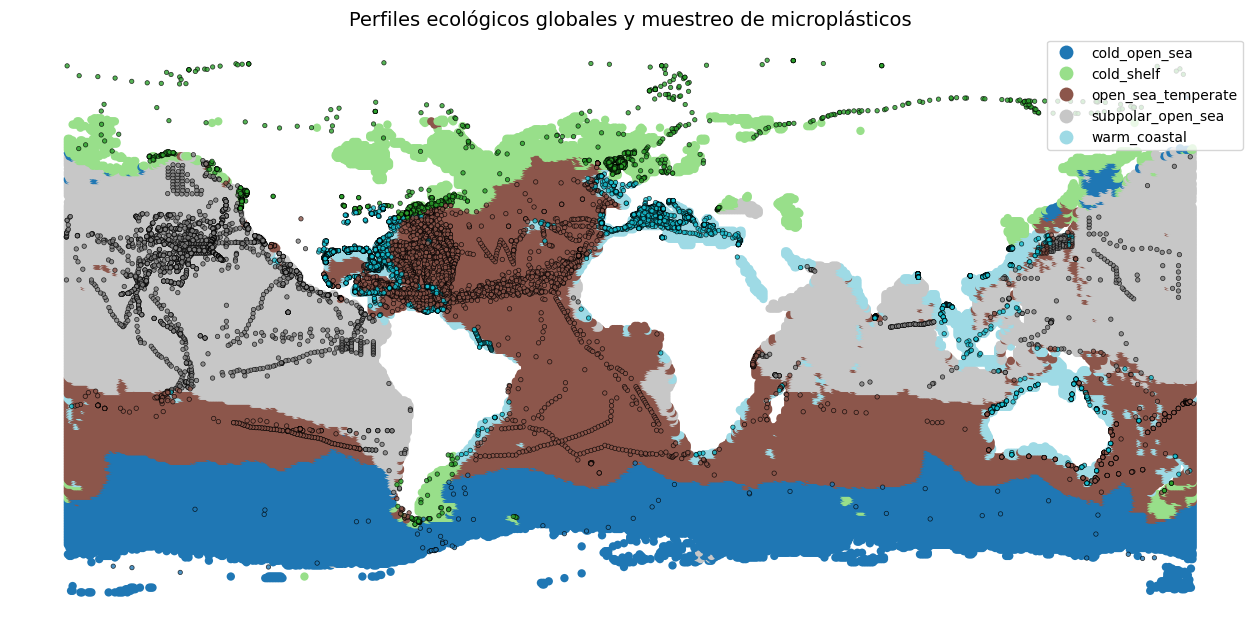

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

# 1️⃣ Grilla (perfiles ecológicos)
grid_gdf.plot(
    column='profile_eco',
    categorical=True,
    cmap='tab20',
    legend=True,
    linewidth=0,
    ax=ax
)

# 2️⃣ Puntos de microplásticos
mp_with_env.plot(
    ax=ax,
    column = 'profile_eco',
    categorical=True,
    markersize=10,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    label='Microplastic samples'
)

ax.set_title("Perfiles ecológicos globales y muestreo de microplásticos", fontsize=14)
ax.set_axis_off()

plt.show()

In [58]:
cols_keep = [
    'mp_id', 'lat', 'lon', 'geometry',
    'microplastics_measurement', 'unit', 'concentration_class_range',
    'mesh_size_mm',
    'distance_to_coast_km',
    'temperature', 'salinity', 'chlorophyll', 'nitrate', 'phosphate',
    'oxygen_dissolved', 'oxygen_utilization',
    'profile_eco', 'dist_deg'
]

mp_clean = mp_with_env[cols_keep]
mp_clean.to_file(
    "../data/GeoDataFrame/gdf_microplastics_with_env.gpkg",
    driver="GPKG"
)
mp_clean

,mp_id,lat,lon,geometry,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,profile_eco,dist_deg
0,0,45.280000,-60.290000,POINT (-60.29 45.28),0.000000,pieces/m3,0-0.0005,0.3350,60.127269,6.299999,32.785152,0.509678,5.787156,0.834564,265.093384,57.033932,cold_shelf,0.350000
1,1,40.930000,-70.650000,POINT (-70.65 40.93),0.002276,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
2,2,40.930000,-70.650000,POINT (-70.65 40.93),0.004320,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
3,3,40.300000,-69.770000,POINT (-69.77 40.3),0.000000,pieces/m3,0-0.0005,0.3350,82.057580,12.127690,34.283134,0.494065,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.304795
4,4,39.880000,-67.150000,POINT (-67.15 39.88),0.000000,pieces/m3,0-0.0005,0.3350,357.363239,8.405213,35.200493,0.848809,14.126949,0.930865,236.792160,56.462185,open_sea_temperate,0.192094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,19317,-5.933333,39.360000,POINT (39.36 -5.93333),188.300000,pieces kg-1 d.w.,150-200,0.0007,102.177974,13.464818,34.985344,0.003898,21.074507,1.583272,147.353027,115.873299,open_sea_temperate,1.141948
19318,19318,-5.500000,39.120000,POINT (39.12 -5.5),155.270000,pieces kg-1 d.w.,150-200,0.0007,46.901614,17.833050,35.093750,0.142112,14.431973,1.130769,162.590759,78.066124,open_sea_temperate,1.332066
19319,19319,-6.450000,39.466667,POINT (39.46667 -6.45),58.070000,pieces kg-1 d.w.,20-150,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,0.766123
19320,19320,-6.320000,39.210000,POINT (39.21 -6.32),210.000000,pieces kg-1 d.w.,>200,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,1.042353


In [59]:
profile_stats = (
    mp_clean
    .groupby('profile_eco')
    .agg(
        n_samples=('mp_id', 'count'),
        mean_conc=('microplastics_measurement', 'mean'),
        median_conc=('microplastics_measurement', 'median'),
        min_conc=('microplastics_measurement', 'min'),
        max_conc=('microplastics_measurement', 'max'),
        p25_conc=('microplastics_measurement', lambda x: x.quantile(0.25)),
        p75_conc=('microplastics_measurement', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

print(profile_stats)
mp_clean

          profile_eco  n_samples    mean_conc  median_conc  min_conc  \
0       cold_open_sea         69     3.083388     0.002449       0.0   
1          cold_shelf       2296    58.060374     0.005760       0.0   
2  open_sea_temperate       5557   447.395117     0.010800       0.0   
3   subpolar_open_sea       2666   143.483138     0.126613       0.0   
4        warm_coastal       8734  1016.510703     0.078947       0.0   

   max_conc  p25_conc  p75_conc  
0      41.0   0.00000  0.017000  
1   40510.0   0.00000  0.034858  
2  126000.0   0.00200  0.053996  
3   57665.0   0.00300  1.674745  
4  800000.0   0.00216  1.399666  


,mp_id,lat,lon,geometry,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,profile_eco,dist_deg
0,0,45.280000,-60.290000,POINT (-60.29 45.28),0.000000,pieces/m3,0-0.0005,0.3350,60.127269,6.299999,32.785152,0.509678,5.787156,0.834564,265.093384,57.033932,cold_shelf,0.350000
1,1,40.930000,-70.650000,POINT (-70.65 40.93),0.002276,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
2,2,40.930000,-70.650000,POINT (-70.65 40.93),0.004320,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
3,3,40.300000,-69.770000,POINT (-69.77 40.3),0.000000,pieces/m3,0-0.0005,0.3350,82.057580,12.127690,34.283134,0.494065,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.304795
4,4,39.880000,-67.150000,POINT (-67.15 39.88),0.000000,pieces/m3,0-0.0005,0.3350,357.363239,8.405213,35.200493,0.848809,14.126949,0.930865,236.792160,56.462185,open_sea_temperate,0.192094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,19317,-5.933333,39.360000,POINT (39.36 -5.93333),188.300000,pieces kg-1 d.w.,150-200,0.0007,102.177974,13.464818,34.985344,0.003898,21.074507,1.583272,147.353027,115.873299,open_sea_temperate,1.141948
19318,19318,-5.500000,39.120000,POINT (39.12 -5.5),155.270000,pieces kg-1 d.w.,150-200,0.0007,46.901614,17.833050,35.093750,0.142112,14.431973,1.130769,162.590759,78.066124,open_sea_temperate,1.332066
19319,19319,-6.450000,39.466667,POINT (39.46667 -6.45),58.070000,pieces kg-1 d.w.,20-150,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,0.766123
19320,19320,-6.320000,39.210000,POINT (39.21 -6.32),210.000000,pieces kg-1 d.w.,>200,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,1.042353


In [61]:
mp_clean = mp_clean.dropna(subset=['microplastics_measurement', 'mesh_size_mm'])

# Comprobar que se eliminaron los nulos
mp_clean.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 14155 entries, 0 to 19321
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   mp_id                      14155 non-null  int64   
 1   lat                        14155 non-null  float64 
 2   lon                        14155 non-null  float64 
 3   geometry                   14155 non-null  geometry
 4   microplastics_measurement  14155 non-null  float64 
 5   unit                       14155 non-null  object  
 6   concentration_class_range  14155 non-null  object  
 7   mesh_size_mm               14155 non-null  float64 
 8   distance_to_coast_km       14155 non-null  float64 
 9   temperature                14155 non-null  float32 
 10  salinity                   14155 non-null  float32 
 11  chlorophyll                14155 non-null  float32 
 12  nitrate                    14155 non-null  float32 
 13  phosphate                  1

In [62]:
# Estadísticas descriptivas
mp_clean['microplastics_measurement'].describe()


count     14155.000000
mean        504.973226
std        9254.932732
min           0.000000
25%           0.002000
50%           0.017280
75%           0.312500
max      800000.000000
Name: microplastics_measurement, dtype: float64

In [67]:
bins = [0, 1, 10, mp_clean['microplastics_measurement'].max()]  # ajusta según describe()
labels = ['low', 'medium', 'high']

# Crear nueva columna con rangos
mp_clean['concentration_class_range'] = pd.cut(
    mp_clean['microplastics_measurement'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Revisar la distribución por rango
mp_clean['concentration_class_range'].value_counts()


/usr/local/python/3.12.1/lib/python3.12/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


concentration_class_range
low       11722
medium     1226
high       1207
Name: count, dtype: int64

In [68]:
features = ['temperature', 'salinity', 'chlorophyll', 'nitrate',
            'phosphate', 'oxygen_dissolved', 'oxygen_utilization']
target = 'concentration_class_range'  
X = mp_clean[features]
y = mp_clean[target]


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [70]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

        high       0.70      0.63      0.66       230
         low       0.93      0.96      0.95      2342
      medium       0.62      0.49      0.55       259

    accuracy                           0.89      2831
   macro avg       0.75      0.69      0.72      2831
weighted avg       0.88      0.89      0.89      2831

